# Sistema de Recuperacion de Informacion Multimodal con RAG

**Asignatura:** Recuperacion de Informacion
**Corpus:** Amazon Shopping Queries Dataset (ESCI) + SQID (Shopping Queries Image Dataset)

---

- **Integrantes**: Michael Enríquez y Aubertin Ochoa
- **Fecha**: 22 de Julio, 2024

---

Este notebook orquesta el pipeline completo llamando a las funciones definidas en `src/`.
No se reimplementa logica aqui: cada fase importa y ejecuta los modulos correspondientes.

**Estructura:** primero se construye todo el sistema (corpus, embeddings, indice FAISS,
componentes de RAG y de las funcionalidades de excelencia). Las pruebas, demostraciones y
resultados con multiples queries de ejemplo estan al final, en la seccion **"Pruebas y
resultados"**.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd()))

import pandas as pd
from IPython.display import display, Image as IPImage

from src import config


---
## Fase A: Preparacion del corpus

Se unen dos fuentes:
- **ESCI** (`tasksource/esci`, subconjunto test/us/small_version=1): texto de queries, texto de
  productos y etiquetas de relevancia (`esci_label`) que usamos como *qrels*.
- **SQID** (`crossingminds/shopping-queries-image-dataset`): URLs de imagen de cada producto.

El join se hace por `product_id` (ASIN). Luego se muestrea un subconjunto de queries
(manteniendo TODOS sus productos asociados, para preservar qrels validos) y se descargan
las imagenes localmente.


In [2]:
from src.data_loading import construir_dataset_unido

# construir_dataset_unido() descarga (o lee de cache local) ESCI + SQID y los une por product_id
joined = construir_dataset_unido()
print("Filas unidas (query, producto):", joined.shape)
print("Productos unicos:", joined.product_id.nunique())
print("Queries unicas:", joined.query_id.nunique())
print("Cobertura de imagen:", f"{joined.image_url.notna().mean():.2%}")
joined.head(3)


c:\Users\Michael\Documents\7mo\MultiRAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Filas unidas (query, producto): (185361, 15)
Productos unicos: 164900
Queries unicas: 8956
Cobertura de imagen: 95.28%


,example_id,query,query_id,product_id,product_locale,esci_label,small_version,large_version,product_title,product_description,product_bullet_point,product_brand,product_color,product_text,image_url
0,48617,110cfm bathroom exhaust fan without light,1750,B076Q7V5WX,us,Exact,1,1,Panasonic FV-0511VQ1 WhisperCeiling DC Ventila...,NaN,Installation: Features a 4-inch or 6-inch duct...,Panasonic,White,Panasonic FV-0511VQ1 WhisperCeiling DC Ventila...,https://m.media-amazon.com/images/I/6180aLQUQ-...
1,1021805,household ventilation fans,51549,B076Q7V5WX,us,Exact,1,1,Panasonic FV-0511VQ1 WhisperCeiling DC Ventila...,NaN,Installation: Features a 4-inch or 6-inch duct...,Panasonic,White,Panasonic FV-0511VQ1 WhisperCeiling DC Ventila...,https://m.media-amazon.com/images/I/6180aLQUQ-...
2,48636,110cfm bathroom exhaust fan without light,1750,B075ZBF9HG,us,Irrelevant,1,1,Panasonic FV-0510VSL1 WhisperValue DC Ventilat...,NaN,Installation: Features a low profile can ideal...,Panasonic,White,Panasonic FV-0510VSL1 WhisperValue DC Ventilat...,https://m.media-amazon.com/images/I/610A7BrOCW...


In [3]:
from src.corpus_builder import construir_corpus

# force_rebuild=False reutiliza el corpus ya construido en data/processed/ si existe.
# construir_corpus() muestrea queries, arma la tabla de productos y descarga sus imagenes.
products, qrels_sample = construir_corpus(force_rebuild=False)

print("Productos en el corpus (con imagen descargada):", products.shape)
print("Pares (query, producto) para evaluacion:", qrels_sample.shape)
print("Queries de evaluacion:", qrels_sample.query_id.nunique())
products[["product_id", "product_title", "document", "image_path"]].head(3)


Productos en el corpus (con imagen descargada): (2852, 10)
Pares (query, producto) para evaluacion: (2927, 4)
Queries de evaluacion: 150


,product_id,product_title,document,image_path
0,B01K8PEZMU,Majestic Pure Himalayan Salt Body Scrub with L...,Title: Majestic Pure Himalayan Salt Body Scrub...,C:\Users\Michael\Documents\7mo\MultiRAG\data\i...
1,B0028SCBV8,Custom Self-Inking Stamp - Up to 3 Lines - 11 ...,Title: Custom Self-Inking Stamp - Up to 3 Line...,C:\Users\Michael\Documents\7mo\MultiRAG\data\i...
2,B07SPZ2HGT,DAYBETTER Led Strip Lights 32.8ft 5050 RGB 300...,Title: DAYBETTER Led Strip Lights 32.8ft 5050 ...,C:\Users\Michael\Documents\7mo\MultiRAG\data\i...


---
## Fase B: Representacion mediante Embeddings (CLIP)

Se usa un modelo CLIP (`openai/clip-vit-base-patch32` via `transformers`) para proyectar
texto e imagen al mismo espacio vectorial. Cada producto se representa con un unico vector
multimodal (promedio ponderado de su embedding de texto y de imagen, renormalizado).


In [4]:
from src.embeddings import ClipEmbedder
import numpy as np
from tqdm.auto import tqdm

embedder = ClipEmbedder()

# Un embedding multimodal por producto: promedio ponderado del embedding de texto
# (titulo + marca + color + features + descripcion) y el de su imagen, renormalizado.
product_embeddings = np.stack([
    embedder.codificar_documento_multimodal(row.document, row.image_path)
    for row in tqdm(products.itertuples(index=False), total=len(products), desc="Embeddings CLIP")
])

print("Shape embeddings:", product_embeddings.shape)
print("Norma del primer vector (debe ser ~1.0):", np.linalg.norm(product_embeddings[0]))


Embeddings CLIP: 100%|██████████| 2852/2852 [05:27<00:00,  8.70it/s]

Shape embeddings: (2852, 512)
Norma del primer vector (debe ser ~1.0): 1.0


---
## Fase C: Base de datos vectorial (FAISS)

Se indexan los embeddings en un `IndexFlatIP` (producto interno sobre vectores normalizados
= similitud coseno). El indice y sus metadatos se persisten en `data/faiss_index/`.


In [5]:
from src.vector_store import FaissVectorStore

store = FaissVectorStore(dim=product_embeddings.shape[1])
store.construir(product_embeddings, products)
store.guardar(config.INDEX_DIR)
print("Documentos indexados:", store.index.ntotal)


Documentos indexados: 2852


---
## Fase D: Sistema RAG (retrieve -> context -> generate)

`src/rag.py` implementa el pipeline completo: recuperacion (con **Query Expansion** opcional
via LLM), **re-ranking** con CrossEncoder, construccion de contexto y generacion de respuesta
con Gemini. La funcion devuelve tambien las evidencias usadas (texto, imagen, score) para
cumplir el requisito de transparencia/trazabilidad.

En esta fase solo se instancian los componentes y se define la funcion de despliegue de
resultados; las ejecuciones de ejemplo estan en la seccion final de pruebas.

> Requiere `GEMINI_API_KEY` configurada en un archivo `.env` en la raiz del proyecto.


In [6]:
from src.reranker import Reranker

reranker = Reranker()


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 5886.00it/s]


In [7]:
def mostrar_resultado_rag(result, max_chars=300):
    """Imprime en formato legible el resultado de pipeline_rag: consulta, respuesta y evidencias."""
    print("=" * 90)
    print("CONSULTA:", result["query"])
    if result["effective_query"] != result["query"]:
        print("CONSULTA EFECTIVA (memoria):", result["effective_query"])
    if result.get("query_variants"):
        print("REFORMULACIONES (query expansion):", result["query_variants"])
    print("=" * 90)
    print("\nRESPUESTA GENERADA:\n")
    print(result["answer"])
    print("\n" + "-" * 90)
    print(f"EVIDENCIAS UTILIZADAS ({len(result['evidences'])}):")
    print("-" * 90)
    for i, ev in enumerate(result["evidences"], start=1):
        score = ev.get("rerank_score", ev.get("score"))
        print(f"\n[Evidencia {i}] score: {score:.4f} | {ev['product_title']}")
        if ev.get("image_path"):
            display(IPImage(filename=ev["image_path"], width=120))
        texto = ev["document"]
        print(texto[:max_chars] + ("..." if len(texto) > max_chars else ""))
    print("\n" + "=" * 90)


---
## Fase E: Interfaz conversacional (Streamlit)

La interfaz de chat vive en `app/streamlit_app.py` y reutiliza exactamente estos mismos
modulos (`ClipEmbedder`, `FaissVectorStore`, `Reranker`, `pipeline_rag`, `ConversationMemory`,
`FeedbackStore`). Presenta la respuesta, las imagenes/evidencias recuperadas, el score de
cada una, botones de "Me gusta"/"No me gusta" (relevance feedback) y mantiene memoria de la
conversacion. Tambien muestra que reformulaciones de query expansion se usaron en cada
busqueda, para mantener la misma trazabilidad que en este notebook.

Para ejecutarla:
```bash
streamlit run app/streamlit_app.py
```


---
## Fase F: Evaluacion experimental

Se evalua el sistema de recuperacion (FAISS + CLIP, con y sin re-ranking) contra los qrels
reales derivados de `esci_label` (Exact/Substitute/Complement/Irrelevant) para las queries
muestreadas. Metricas: **Precision@k**, **Recall@k**, **NDCG@k** (k = 3, 5, 10).

Aqui solo se define el conjunto de queries de evaluacion y las funciones de busqueda; la
ejecucion de la evaluacion esta en la seccion final de pruebas.


In [8]:
from src.evaluation import evaluar_sistema, resumir

eval_queries = qrels_sample[["query_id", "query"]].drop_duplicates().reset_index(drop=True)
print("Queries de evaluacion disponibles:", len(eval_queries))


def funcion_busqueda_base(query_text):
    """Ranking de referencia: solo similitud coseno CLIP via FAISS, sin re-ranking."""
    q_emb = embedder.codificar_consulta(query_text)
    hits = store.buscar(q_emb, top_k=10)
    return [h["product_id"] for h in hits]


def funcion_busqueda_rerankeada(query_text):
    """Mismo candidato inicial de FAISS, pero reordenado con el CrossEncoder (re-ranking)."""
    q_emb = embedder.codificar_consulta(query_text)
    candidates = store.buscar(q_emb, top_k=config.TOP_K_RETRIEVE)
    reranked = reranker.rerankear(query_text, candidates, top_k=10)
    return [h["product_id"] for h in reranked]


Queries de evaluacion disponibles: 150


---
## Funcionalidades de excelencia (componentes)

- **Re-ranking (+15)**: ya instanciado arriba (`reranker`).
- **Query Expansion (+15)**: `src/query_expansion.expandir_consulta` / `recuperar_multi_consulta`,
  sin estado, se usa directo en la seccion de pruebas.
- **Relevance Feedback (+15)**: `FeedbackStore`, mantiene estado por sesion.
- **Memoria conversacional (+15)**: `ConversationMemory`, mantiene el historial de turnos.

Se instancian aqui los componentes con estado; se ejercitan en la seccion final.


In [9]:
from src.feedback import FeedbackStore
from src.memory import ConversationMemory

feedback = FeedbackStore()
memory = ConversationMemory()


---
---

# Pruebas y resultados

A partir de aca se ejercita todo lo construido arriba con **multiples queries de ejemplo**.
Se usa una query conocida ("wireless bluetooth headphones", ya validada manualmente) mas
varias queries reales tomadas al azar del propio conjunto de evaluacion (`qrels_sample`), de
forma que las pruebas queden ancladas a productos con relevancia juzgada realmente en el
corpus muestreado.


In [10]:
KNOWN_GOOD_QUERY = "wireless bluetooth headphones"

sampled_queries = (
    qrels_sample["query"]
    .drop_duplicates()
    .sample(n=5, random_state=config.RANDOM_SEED)
    .tolist()
)

TEST_QUERIES = [KNOWN_GOOD_QUERY] + [q for q in sampled_queries if q != KNOWN_GOOD_QUERY]

print(f"Queries de prueba ({len(TEST_QUERIES)}):")
for q in TEST_QUERIES:
    print(" -", q)


Queries de prueba (6):
 - wireless bluetooth headphones
 - nike cortez mens
 - portable foot tube
 - dorm safe
 - lg hbs tone retractable
 - adult aladdin genie costume


## Prueba 1: Recuperacion FAISS pura (sin RAG)

Similitud coseno directa entre el embedding CLIP de la query y el indice, sin re-ranking ni
generacion.


In [11]:
for q in TEST_QUERIES:
    print("=" * 90)
    print("QUERY:", q)
    hits = store.buscar(embedder.codificar_consulta(q), top_k=5)
    for i, h in enumerate(hits, start=1):
        print(f"  [{i}] score={h['score']:.4f} | {h['product_title']}")
print("=" * 90)


QUERY: wireless bluetooth headphones
  [1] score=0.6229 | Episode 1
  [2] score=0.6209 | Episode 1
  [3] score=0.6113 | Wireless Headset
  [4] score=0.6096 | LG Tone Style HBS-SL5 Bluetooth Wireless Stereo Neckband Earbuds Tuned by Meridian Audio
  [5] score=0.6069 | Episode 2 (Full UK-Length Edition)
QUERY: nike cortez mens
  [1] score=0.7087 | Nike Cortez 72 S.d. Mens Cj2586-102 Size 10.5
  [2] score=0.7056 | Nike Cortez (GS) Sneaker Shoes different colors, White/Black, 6.5 Big Kid
  [3] score=0.6859 | Nike Men's Cortez Basic SE Casual Shoes (12, Black/White/University Red/Kinetic)
  [4] score=0.6844 | Nike Cortez Basic Leather OG Mens Fashion-Sneakers 882254-164_12 - White/Varsity RED-Varsity Royal
  [5] score=0.6563 | Nike Men's Classic Cortez Leather Running Shoes, Black/Mettalic Silver/White, 10.5
QUERY: portable foot tube
  [1] score=0.6157 | Fat, Sick & Nearly Dead 2
  [2] score=0.6087 | An Extra Hand
  [3] score=0.6017 | Episode 1
  [4] score=0.6015 | Episode 5
  [5] score=0.6

## Prueba 2: Pipeline RAG completo (retrieve + rerank + generar)

Se ejecuta el pipeline completo (`pipeline_rag`) sobre una query de prueba: recuperacion con
query expansion, re-ranking con CrossEncoder, generacion con Gemini y despliegue de
evidencias (texto + imagen + score). La respuesta generada ahora tambien abre con un resumen
breve de cuantos productos se encontraron (ver regla 6 del prompt en `src/rag.py`).


CONSULTA: nike cortez mens
REFORMULACIONES (query expansion): ['zapatillas nike cortez hombre', 'nike cortez clasicas hombre', 'nike cortez para caballero']

RESPUESTA GENERADA:

*: Nike Men's Classic Cortez Leather Running Shoes, Black/Mettalic Silver/White, 10.5. Brand: Nike. Color

------------------------------------------------------------------------------------------
EVIDENCIAS UTILIZADAS (5):
------------------------------------------------------------------------------------------

[Evidencia 1] score: 8.2374 | Nike Cortez 72 S.d. Mens Cj2586-102 Size 10.5


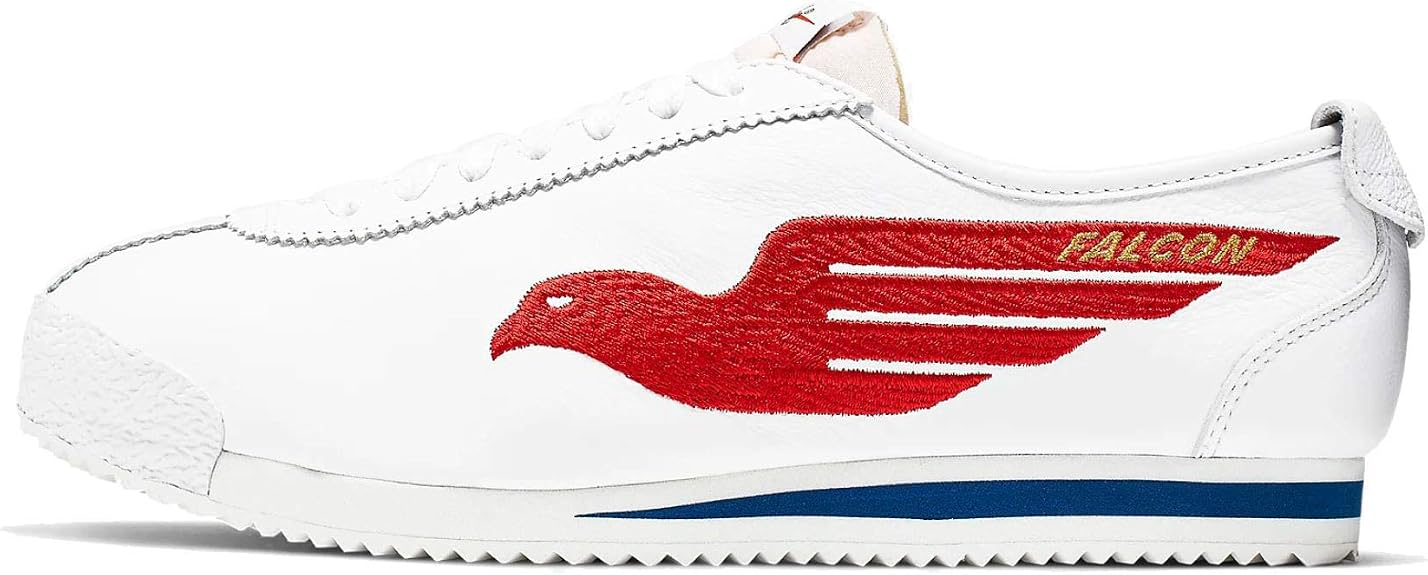

Title: Nike Cortez 72 S.d. Mens Cj2586-102 Size 10.5
Brand: Nike
Color: White/Varsity Red-game Royal

[Evidencia 2] score: 8.1843 | Nike Cortez Basic Leather OG Mens Fashion-Sneakers 882254-164_12 - White/Varsity RED-Varsity Royal


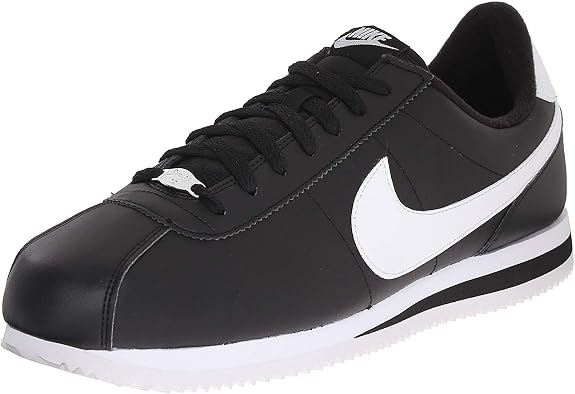

Title: Nike Cortez Basic Leather OG Mens Fashion-Sneakers 882254-164_12 - White/Varsity RED-Varsity Royal
Brand: Nike
Color: White/Varsity Red
Features: sku=882254-164-12
Description: Designed by Nike co-founder Bill Bowerman, the Nike Cortez has been continuously produced since it debuted in 1972. ...

[Evidencia 3] score: 7.9258 | Nike Men's Classic Cortez Leather Running Shoes, Black/Mettalic Silver/White, 10.5


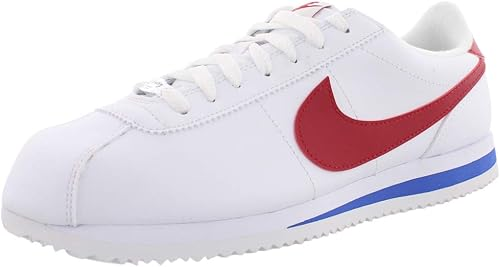

Title: Nike Men's Classic Cortez Leather Running Shoes, Black/Mettalic Silver/White, 10.5
Brand: Nike
Color: Black/Mettalic Silver/White
Features: sku=819719-012-10.5
Description: Designed by Nike co-founder Bill Bowerman, the Nike Cortez has been continuously produced since it debuted in 1972. This...

[Evidencia 4] score: 7.6694 | Nike Men's Classic Cortez Leather Fashion Sneakers (7.5)


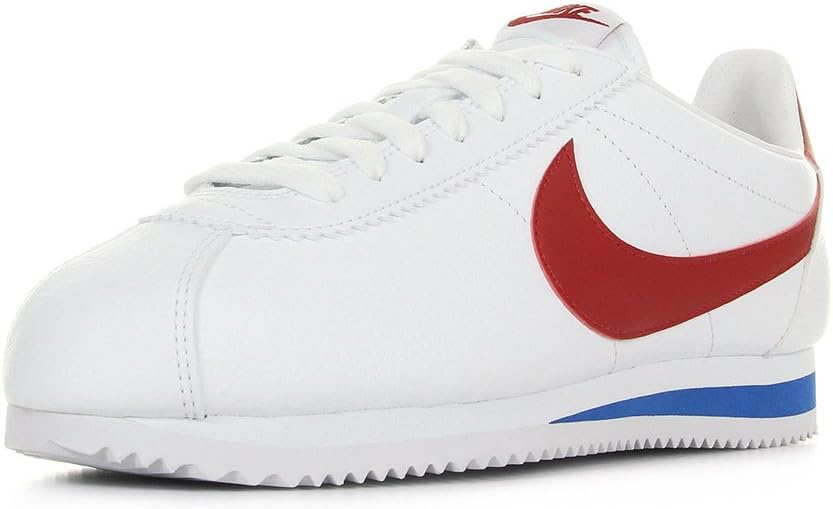

Title: Nike Men's Classic Cortez Leather Fashion Sneakers (7.5)
Brand: Nike
Color: White (White/Varsity Royal/Varsity Red)
Features: Shoes
Description: Nike Men Classic Cortez Leather white varsity red-varsity royal

[Evidencia 5] score: 7.2862 | Nike Men's Cortez Basic SE Casual Shoes (12, Black/White/University Red/Kinetic)


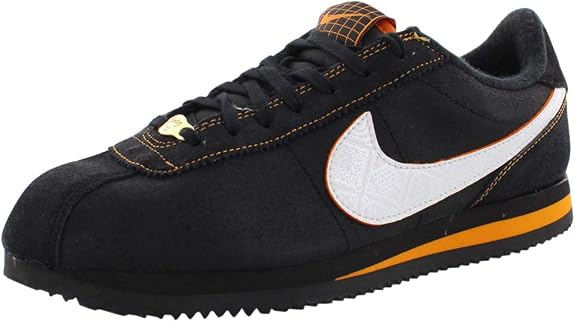

Title: Nike Men's Cortez Basic SE Casual Shoes (12, Black/White/University Red/Kinetic)
Brand: Nike
Color: Black



In [12]:
from src.rag import pipeline_rag

q = TEST_QUERIES[1]

result = pipeline_rag(
    q,
    embedder=embedder,
    store=store,
    reranker=reranker,
    use_query_expansion=True,
)

mostrar_resultado_rag(result)


## Prueba 3: Evaluacion cuantitativa (Precision@k, Recall@k, NDCG@k)

Evaluacion sobre **todas** las queries del conjunto muestreado (no solo `TEST_QUERIES`),
comparando el ranking base (solo FAISS/CLIP) contra el ranking con re-ranking.


In [13]:
results_base = evaluar_sistema(funcion_busqueda_base, eval_queries, qrels_sample)
results_reranked = evaluar_sistema(funcion_busqueda_rerankeada, eval_queries, qrels_sample)

print("=== Solo FAISS (CLIP) ===")
print(resumir(results_base))
print("\n=== FAISS + Re-ranking (CrossEncoder) ===")
print(resumir(results_reranked))


=== Solo FAISS (CLIP) ===
precision@3     0.524444
recall@3        0.112789
ndcg@3          0.470516
precision@5     0.502667
recall@5        0.174561
ndcg@5          0.458752
precision@10    0.446667
recall@10       0.300423
ndcg@10         0.444160
dtype: float64

=== FAISS + Re-ranking (CrossEncoder) ===
precision@3     0.651111
recall@3        0.139236
ndcg@3          0.598522
precision@5     0.609333
recall@5        0.211309
ndcg@5          0.571861
precision@10    0.502000
recall@10       0.336202
ndcg@10         0.522656
dtype: float64


Comparar `results_base` vs `results_reranked` permite cuantificar el aporte del
re-ranking (funcionalidad de excelencia) sobre la calidad del ranking inicial. En la ultima
corrida, el re-ranking con CrossEncoder mejoro Precision@3 (0.524 -> 0.651) y NDCG@3
(0.471 -> 0.599), con ganancias similares en k=5 y k=10: el CrossEncoder, al evaluar
conjuntamente query y documento (en vez de comparar embeddings independientes), corrige
casos donde la similitud vectorial CLIP trae resultados semanticamente cercanos pero
irrelevantes (por ejemplo, titulos genericos de peliculas/episodios que matchean por
casualidad). Para el informe tecnico, incluir esta tabla y un analisis de en que tipo de
consultas mejora o empeora el re-ranking.


## Prueba 4: Query Expansion

Reformulaciones generadas por el LLM para algunas de las queries de prueba. Se piden en
formato JSON estructurado (`response_schema=list[str]`) para evitar que el modelo devuelva
numeracion, vinetas u otro texto suelto junto con las reformulaciones.


In [14]:
from src.query_expansion import expandir_consulta

for q in TEST_QUERIES[:3]:
    print("QUERY:", q)
    print("  Expansiones:", expandir_consulta(q))
    print()


QUERY: wireless bluetooth headphones
  Expansiones: ['wireless bluetooth headphones', 'auriculares inalámbricos bluetooth', 'wireless over ear headphones', 'audífonos bluetooth']

QUERY: nike cortez mens
[query_expansion] fallo la expansion, se usa solo la query original: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
  Expansiones: ['nike cortez mens']

QUERY: portable foot tube
  Expansiones: ['portable foot tube', 'tina inflable para pies', 'portable foot bath basin', 'cubo plegable para pedicura']



## Prueba 5: Relevance Feedback (Rocchio)

Simulacion de un usuario marcando "me gusta"/"no me gusta" sobre los resultados de
`KNOWN_GOOD_QUERY`, y como afecta la siguiente busqueda de la misma sesion via el ajuste de
Rocchio sobre el vector de consulta.


In [15]:
session_id = "demo-session"

first_pass = store.buscar(embedder.codificar_consulta(KNOWN_GOOD_QUERY), top_k=5)
print("Antes de feedback:")
for r in first_pass:
    print(" -", r["product_title"])

# El usuario marca el primer resultado como 'no me gusta'
feedback.registrar(session_id, first_pass[0]["product_id"], liked=False)
# y el segundo como 'me gusta'
feedback.registrar(session_id, first_pass[1]["product_id"], liked=True)

adjusted_query = feedback.aplicar_rocchio(session_id, embedder.codificar_consulta(KNOWN_GOOD_QUERY), store)
second_pass = store.buscar(adjusted_query, top_k=5)

print("\nDespues de feedback:")
for r in second_pass:
    print(" -", r["product_title"])


Antes de feedback:
 - Episode 1
 - Episode 1
 - Wireless Headset
 - LG Tone Style HBS-SL5 Bluetooth Wireless Stereo Neckband Earbuds Tuned by Meridian Audio
 - Episode 2 (Full UK-Length Edition)

Despues de feedback:
 - Episode 1
 - Episode 5
 - Episode 1
 - Episode 1
 - Episode 2 (Full UK-Length Edition)


## Prueba 6: Memoria conversacional

El sistema reformula preguntas de seguimiento en consultas autocontenidas usando el
historial de la conversacion (turno 1 con `KNOWN_GOOD_QUERY`, turno 2 una pregunta de
seguimiento que depende del contexto).


[rag] intento 1/1 fallo (503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}); reintentando en 1.2s
CONSULTA: wireless bluetooth headphones

RESPUESTA GENERADA:

No fue posible generar una respuesta en este momento debido a alta demanda del servicio.

------------------------------------------------------------------------------------------
EVIDENCIAS UTILIZADAS (5):
------------------------------------------------------------------------------------------

[Evidencia 1] score: 4.4937 | LG TONE Ultra Α Bluetooth Wireless Stereo Neckband Earbuds (Hbs-830) - Black


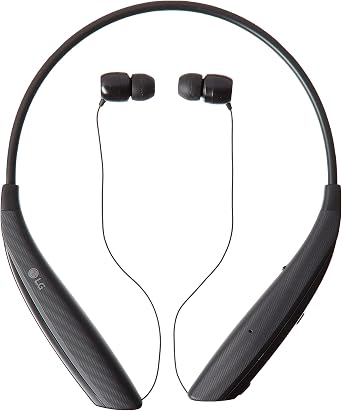

Title: LG TONE Ultra Α Bluetooth Wireless Stereo Neckband Earbuds (Hbs-830) - Black
Brand: LG
Color: Black
Features: Advanced Quad layer speaker technology
Dual mems microphones - delivers crystal clear conversation
Delivers crystal clear conversation
Slim & sleek design with small/ light retractabl...

[Evidencia 2] score: 2.7910 | LG Tone Flex HBS-XL7 Bluetooth Wireless Stereo Neckband Earbuds with 32-Bit Hifi DAC Tune by Meridian Audio, Black


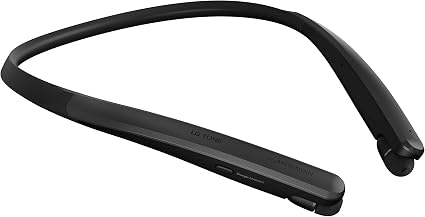

Title: LG Tone Flex HBS-XL7 Bluetooth Wireless Stereo Neckband Earbuds with 32-Bit Hifi DAC Tune by Meridian Audio, Black
Brand: LG
Color: Black
Features: 32-Bit hi-fi dac-get premium-quality sound that lasts for hours. 32-Bit hi-fi DAC upscale audio files to a higher resolution without compromising...

[Evidencia 3] score: 2.5674 | LG Tone Style HBS-SL5 Bluetooth Wireless Stereo Neckband Earbuds Tuned by Meridian Audio


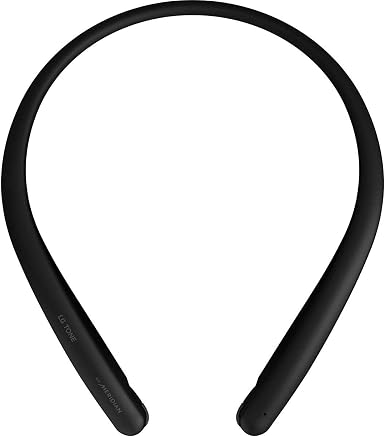

Title: LG Tone Style HBS-SL5 Bluetooth Wireless Stereo Neckband Earbuds Tuned by Meridian Audio
Brand: LG
Color: Black
Features: Sound by meridian-experience three-dimensional audio that’s remarkably close to the original recording with rich bass and clear treble
Power battery life- Talk time 8 hour...

[Evidencia 4] score: 0.8117 | Wireless Headset


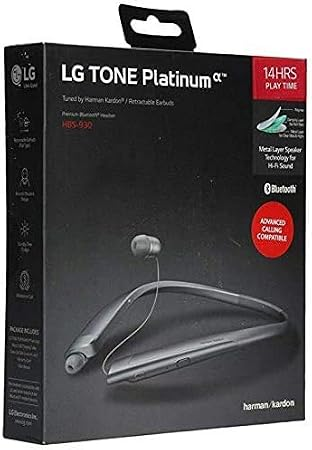

Title: Wireless Headset
Brand: LG
Color: Black
Features: Multi-metal unit technology: producing natural sound with clear highs & less distortion
Tuned and branded by Harman Kardon- delivers crisp treble and robust bass
Retractable wire management - slim & sleek design with small/ light retractable w...

[Evidencia 5] score: 0.1413 | MP3 Player, RUIZU MP3 Player with Bluetooth, Portable HiFi Lossless Sound Music Player with Speaker, FM Radio, Voice Recorder, E-book, Video Player, Pedometer, Built-in 8GB Memory, Support up to 128GB


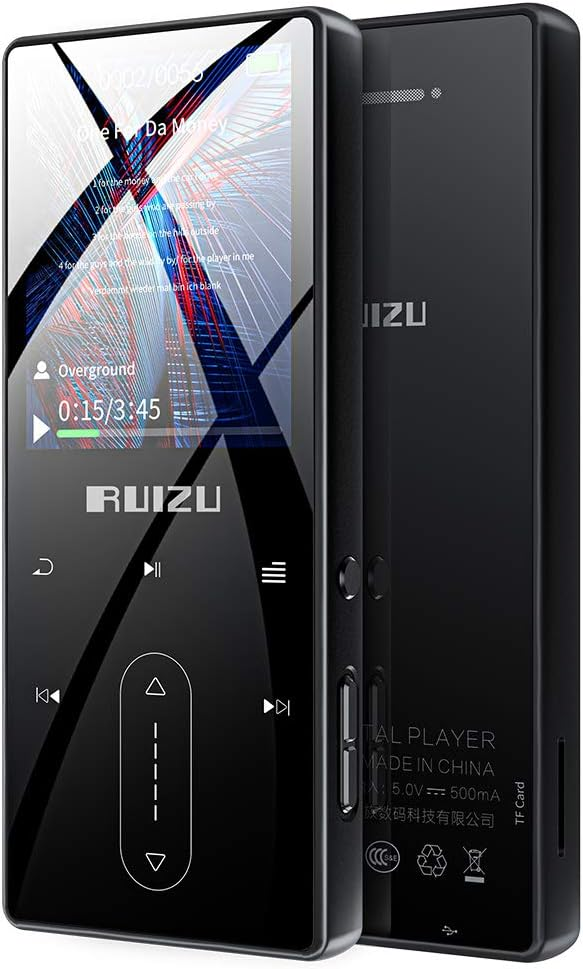

Title: MP3 Player, RUIZU MP3 Player with Bluetooth, Portable HiFi Lossless Sound Music Player with Speaker, FM Radio, Voice Recorder, E-book, Video Player, Pedometer, Built-in 8GB Memory, Support up to 128GB
Brand: RUIZU
Color: 8GB
Features: ✿️【Wireless Upgraded Bluetooth 4.1 Technology】High-speed, ...

[memory] fallo la reescritura, se usa la query original: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
CONSULTA: y en color negro?

RESPUESTA GENERADA:

Se encontraron 5 productos en el catálogo que corresponden a títulos de episodios o contenidos musicales.

Lamentablemente, las evidencias proporcionadas no contienen ninguna información sobre auriculares inalámbricos Bluetooth (wireless bluetooth headphones) ni sobre su disponibilidad en color negro.

-----------------------------------------------------------------------------------------

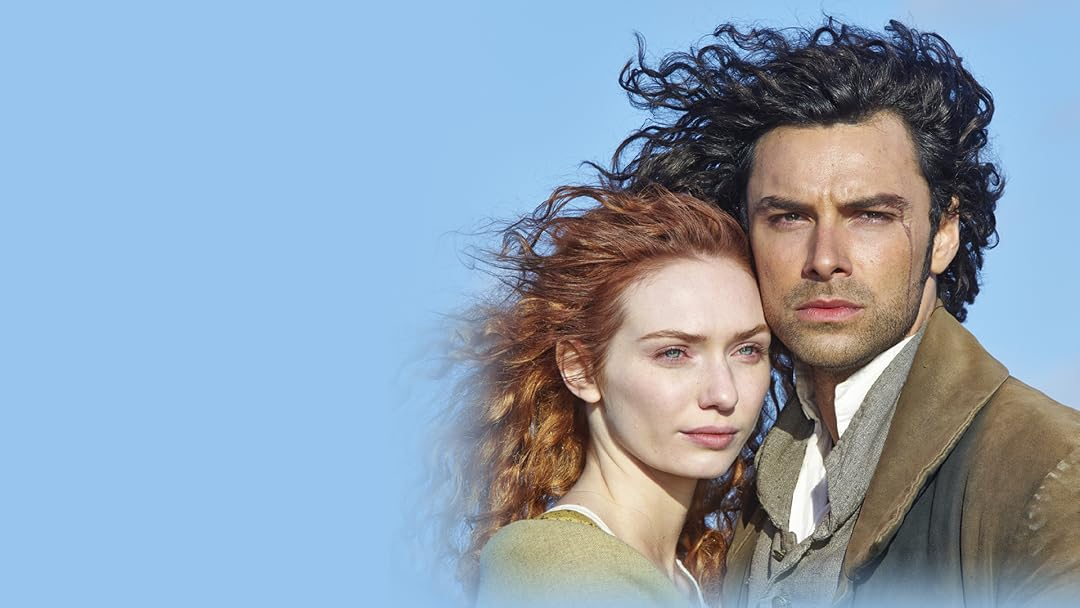

Title: Episode 1

[Evidencia 2] score: -10.8223 | Episode 1


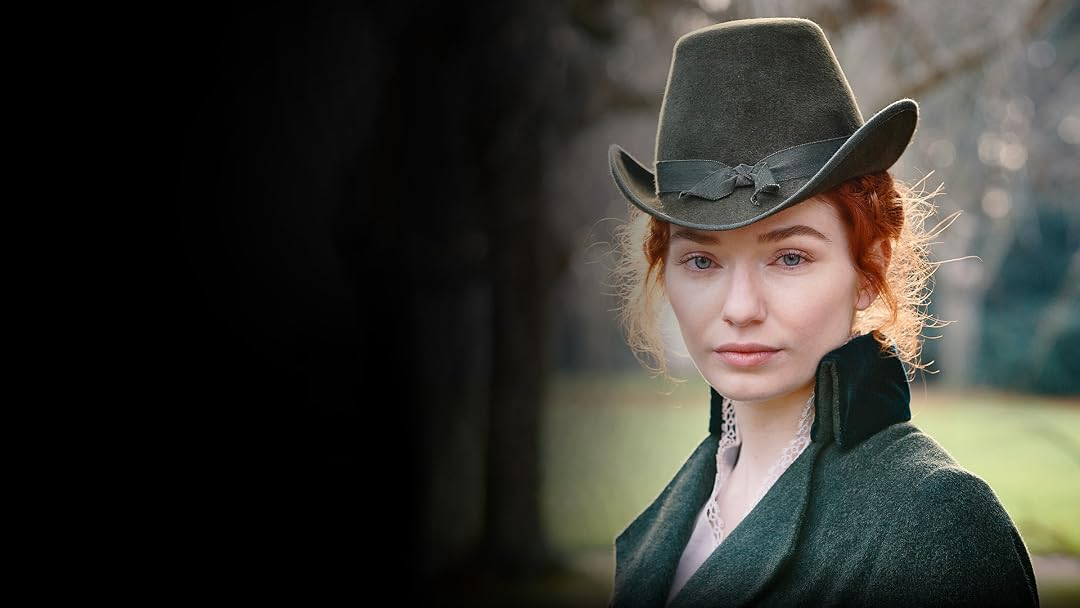

Title: Episode 1

[Evidencia 3] score: -10.8223 | Episode 1


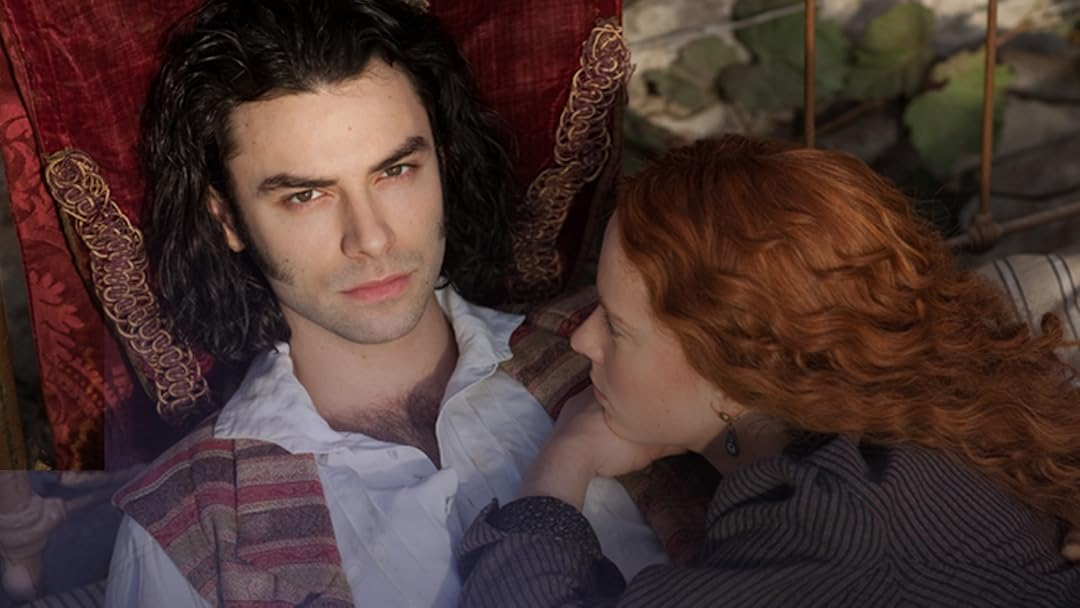

Title: Episode 1

[Evidencia 4] score: -10.9069 | Episode 5


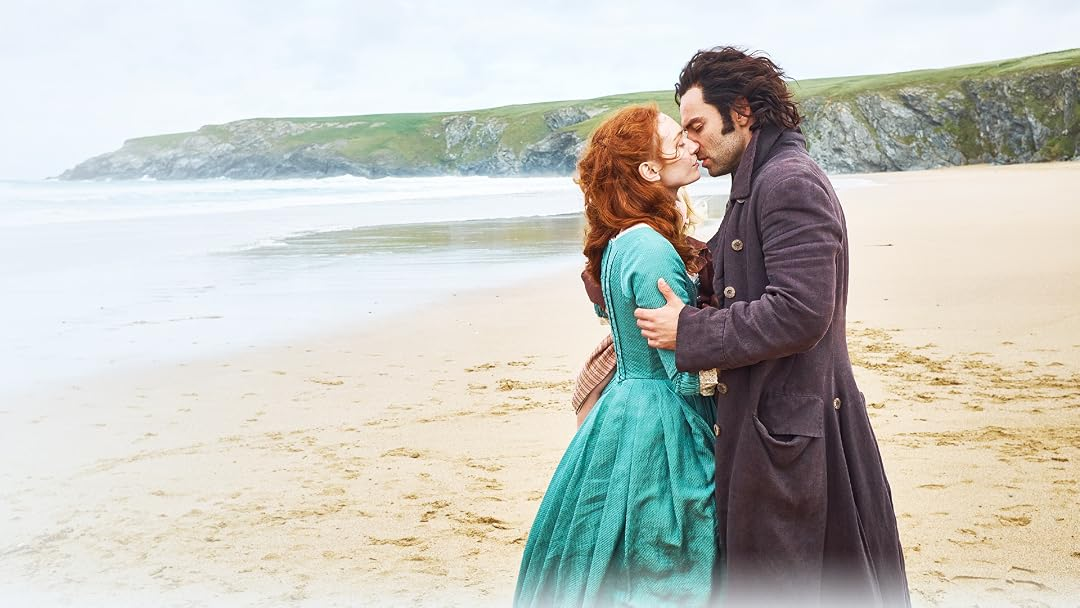

Title: Episode 5

[Evidencia 5] score: -11.0728 | Victim of the Night


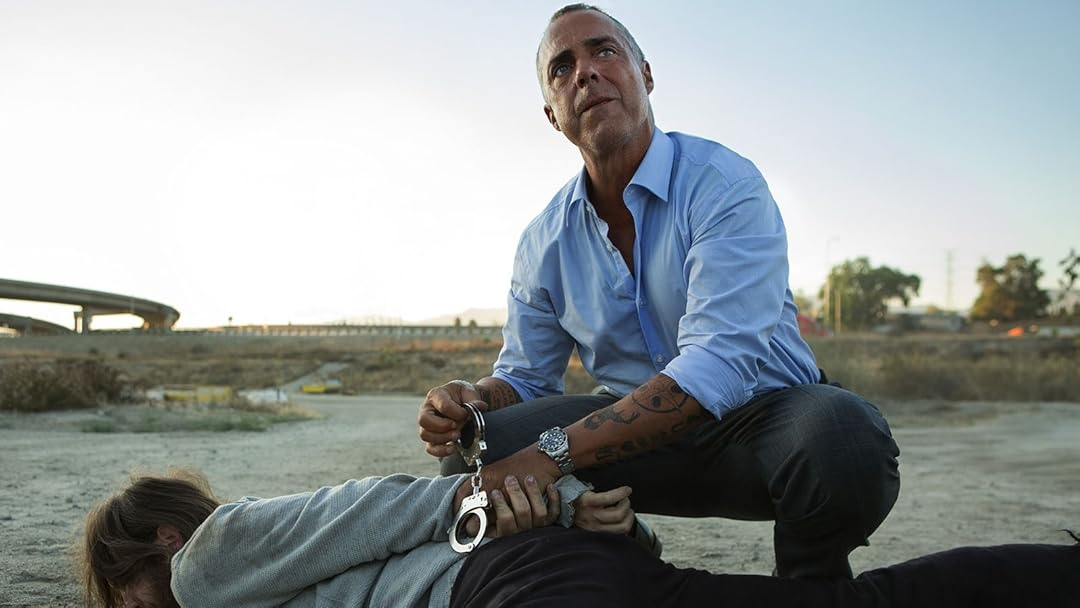

Title: Victim of the Night



In [16]:
r1 = pipeline_rag(KNOWN_GOOD_QUERY, embedder=embedder, store=store,
                   reranker=reranker, memory=memory, use_query_expansion=False)
mostrar_resultado_rag(r1)

r2 = pipeline_rag("y en color negro?", embedder=embedder, store=store,
                   reranker=reranker, memory=memory, use_query_expansion=False)
mostrar_resultado_rag(r2)


---
## Notas finales

- Todo el codigo reutilizable vive en `src/` (y `app/streamlit_app.py` para la interfaz).
  Este notebook solo orquesta las llamadas, en linea con la consigna del proyecto. Los
  nombres de funciones y metodos estan en espanol para que el flujo se lea de corrido junto
  con las explicaciones de cada fase.
- El tamano de muestra (`config.N_QUERIES_SAMPLE`, `config.MAX_PRODUCTS_SAMPLE`) esta
  ajustado para poder correr CLIP en CPU en tiempos razonables. Ver `README.md` para
  instrucciones de instalacion y ejecucion completas.
- El modelo de Gemini usado para generacion, query expansion y memoria se controla desde
  `config.GEMINI_MODEL`; si el modelo configurado deja de estar disponible (Google los va
  deprecando), ese es el unico lugar que hay que actualizar.
